## 1. Import Libraries

In [3]:
# Import the main libraries we will need

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

## 2. Load the Dataset

In [4]:
# Load the Talabat dataset
#first read the data and see how it looks

DATA_PATH = "talabat_enhanced_orders.csv"

df = pd.read_csv(DATA_PATH)

df.head(10)  # show first rows to understand the structure

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,...,Bicycle,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online
6,7,U8948,827,4,Sushi,1,133.94,2025-06-11 04:09:00,2025-06-11 04:49:00,40,...,Bicycle,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online
7,8,U8672,908,109,Shawarma,5,404.80,2025-06-12 18:37:00,2025-06-12 19:18:00,41,...,Bicycle,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online
8,9,U2205,814,215,Pizza,1,101.03,2025-06-01 22:18:00,2025-06-01 23:05:00,47,...,Motorbike,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online
9,10,U7411,362,416,Pizza,1,130.05,2025-06-09 00:18:00,2025-06-09 01:04:00,46,...,Bicycle,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online


## 3. Basic Dataset Info

In [5]:
# Checking the size of the dataset and basic quality issues

print("Shape:", df.shape)

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


## 4. Target Variable

In [6]:
# Our target variable is Order_Status
# I want to see how the classes are distributed

target_col = "Order_Status"

df[target_col].value_counts()

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

## 5. Visualize Target Distribution

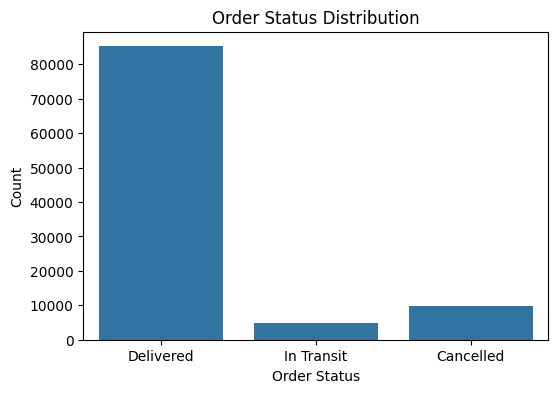

In [7]:
# Visualizing the order status distribution
# This helps to see if the classes are balanced or not

plt.figure(figsize=(6,4))

sns.countplot(x=target_col, data=df)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.show()

## 6. Data Types

In [8]:
# Checking the data types of each column
# This helps to know which columns are numerical or categorical

df.dtypes

Order_ID                       int64
User_ID                          str
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                        str
Quantity                       int64
Total_Price                  float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
City                             str
Payment_Method                   str
Order_Status                     str
Driver_Vehicle                   str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                    str
Driver_Availability              str
dtype: object

## 7. Feature Engineering

In [9]:
# Creating new features from the order time
# Time features can sometimes help the model learn patterns

df_fe = df.copy()

df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek

# weekend indicator
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

df_fe.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0


## 8. Price Feature

In [10]:
# Creating a simple feature: price per item
# This might show if expensive items affect delivery status

df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]

df_fe[["Quantity","Total_Price","price_per_item"]].head(10)

,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


## 9. Reduce High Cardinality

In [11]:
# Some item names appear very rarely
# To simplify the model, I keep only the most common items

if "Item_Name" in df_fe.columns:

    top_k = 20

    top_items = df_fe["Item_Name"].value_counts().head(top_k).index

    df_fe["Item_Name_reduced"] = np.where(
        df_fe["Item_Name"].isin(top_items),
        df_fe["Item_Name"],
        "Other"
    )

    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())

Unique Item_Name: 9
Unique Item_Name_reduced: 9


## 10. Setup and imports

In [12]:
# Creating price categories
# This groups prices into ranges which can help the model

df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0,100,250,500,np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head()

,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high


## 11. Prepare Features and Target

In [13]:
# Removing columns that are IDs or not useful for prediction

drop_cols = [
    "Order_ID",
    "User_ID",
    "Restaurant_ID",
    "Driver_ID",
    "Order_Time",
    "Delivery_Time",
    "Delivery_Duration_Minutes",
    "Item_Name"
]

# keep only existing columns
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("Features shape:", X.shape)

Features shape: (100000, 20)


## 12. Train Test Split

In [14]:
# Splitting data into training and testing sets
# 80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80000, 20)
Test size: (20000, 20)


## 13. Detect Column Types

In [15]:
# Automatically identifying categorical and numerical columns

categorical_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number,"bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'price_per_item']


C:\Users\7agu4\AppData\Local\Temp\ipykernel_19528\1407791982.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()


## 14. Preprocessing + Model Pipeline

In [16]:
# Building preprocessing pipeline
# Categorical columns will be encoded using OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

## 15. Train Model

In [17]:
# Training the Random Forest model

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred),4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



c:\Users\7agu4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\7agu4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\7agu4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 16. Confusion Matrix

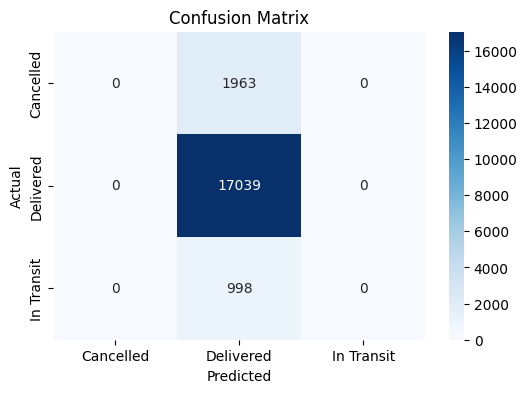

In [18]:
# Visualizing model performance using confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 17. Feature Importance

In [19]:
# Checking which features influence the model the most

ohe = model.named_steps["preprocess"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])

all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)

,feature,importance
39,Delivery_Distance_km,0.078799
43,price_per_item,0.075982
37,Driver_Lat,0.075723
38,Driver_Lon,0.075716
36,Customer_Lon,0.075326
33,Restaurant_Lat,0.075271
35,Customer_Lat,0.075124
34,Restaurant_Lon,0.075106
32,Total_Price,0.074705
40,order_hour,0.053916


## 18. Setup and imports

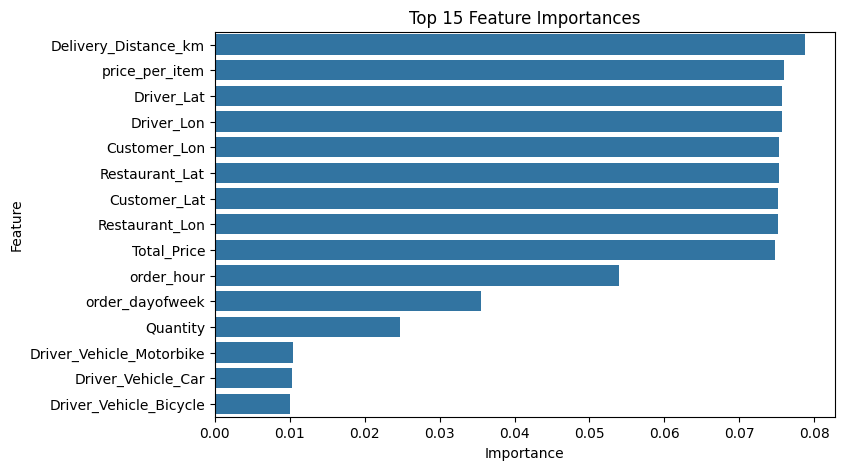

In [20]:
# Visualizing the most important features

plt.figure(figsize=(8,5))

top_n = 15

sns.barplot(
    data=fi.head(top_n),
    x="importance",
    y="feature"
)

plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()